In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Read cleaned datasets
YouGov = pd.read_csv("../Cleaned data/cleaned_YouGov_compare.csv")
policy_data = pd.read_csv("../Cleaned data/cleaned_OxCGRT_policy_data.csv")

print(YouGov.shape)
print(policy_data.shape)

(32163, 18)
(8768, 7)


In [3]:
# Convert date columns to datetime format
YouGov["endtime"] = pd.to_datetime(YouGov["endtime"])
policy_data["Date"] = pd.to_datetime(policy_data["Date"])

In [4]:
# Rename the YouGov date variable for merging
YouGov = YouGov.rename(columns={"endtime": "Date"})

YouGov.head(1)

,Date,i2_health,i9_health,i11_health,age,gender,state,household_size,employment_status,WCRex2,cantril_ladder,WCRex1,r1_1,r1_2,week_number,face_mask_behaviour_binary,protective_behaviour_binary,d1_comorbidities
0,2020-06-24,0.0,Not sure,Not sure,31,Male,Western Australia,1,Full time employment,Not very much confidence,8.0,Somewhat badly,5,1,1,0,0,Yes


In [5]:
# Check whether state names are consistent across the two datasets
YouGov_states = sorted(YouGov["state"].unique())
policy_states = sorted(policy_data["state"].unique())

print(YouGov_states)
print(policy_states)

['Australian Capital Territory', 'New South Wales', 'Northern Territory', 'Queensland', 'South Australia', 'Tasmania', 'Victoria', 'Western Australia']
['Australian Capital Territory', 'New South Wales', 'Northern Territory', 'Queensland', 'South Australia', 'Tasmania', 'Victoria', 'Western Australia']


In [6]:
# Merge YouGov and policy datasets by state and date
# Use inner merge to keep only matched observations and avoid missing values
merged_data = YouGov.merge(
    policy_data,
    on=["state", "Date"],
    how="inner"
)

merged_data.shape

(32163, 23)

In [7]:
print(merged_data.shape)
print(merged_data.columns)

(32163, 23)
Index(['Date', 'i2_health', 'i9_health', 'i11_health', 'age', 'gender',
       'state', 'household_size', 'employment_status', 'WCRex2',
       'cantril_ladder', 'WCRex1', 'r1_1', 'r1_2', 'week_number',
       'face_mask_behaviour_binary', 'protective_behaviour_binary',
       'd1_comorbidities', 'C_policy_mean', 'E_policy_mean', 'H_policy_mean',
       'overall_policy_intensity', 'policy_intensity_level'],
      dtype='object')


In [8]:
# Recalculate cut-off points after merging
lower_cutoff = merged_data["overall_policy_intensity"].quantile(1 / 3)
upper_cutoff = merged_data["overall_policy_intensity"].quantile(2 / 3)

print(lower_cutoff)
print(upper_cutoff)

2.8109
3.291


In [9]:
# def categorise_policy_intensity(value):
#     if value < lower_cutoff:
#         return "low"
#     elif value < upper_cutoff:
#         return "medium"
#     else:
#         return "high"

# merged_data["policy_intensity_level"] = merged_data["overall_policy_intensity"].apply(
#     categorise_policy_intensity
# )

policy_intensity_counts = merged_data["policy_intensity_level"].value_counts()
display(policy_intensity_counts)

policy_intensity_level
high      16700
medium    13700
low        1763
Name: count, dtype: int64

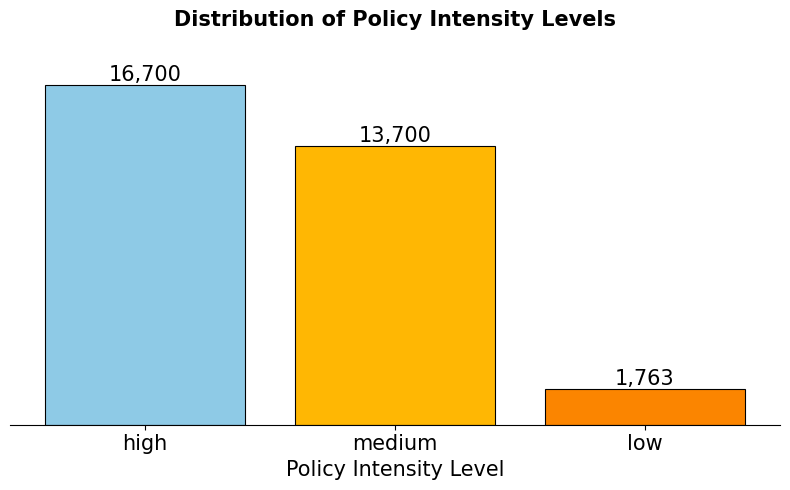

In [10]:
colors = ["#8ecae6", "#ffb703", "#fb8500"]

plt.figure(figsize=(8, 5))

bars = plt.bar(
    policy_intensity_counts.index,
    policy_intensity_counts.values,
    color=colors,
    edgecolor="black",
    linewidth=0.8
)

plt.title("Distribution of Policy Intensity Levels", fontsize=15, fontweight="bold")
plt.xlabel("Policy Intensity Level", fontsize=15)
plt.xticks(fontsize=15)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom",
        fontsize=15
    )

plt.grid(False)

plt.ylabel("")
plt.yticks([])
plt.gca().spines["left"].set_visible(False)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.ylim(0, policy_intensity_counts.max() * 1.15)

plt.tight_layout()

plt.savefig("../Figure/policy_intensity_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [11]:
# Drop variables that are no longer needed
merged_data = merged_data.drop(columns=["Date", "state", "overall_policy_intensity"])

merged_data.head(1)

,i2_health,i9_health,i11_health,age,gender,household_size,employment_status,WCRex2,cantril_ladder,WCRex1,r1_1,r1_2,week_number,face_mask_behaviour_binary,protective_behaviour_binary,d1_comorbidities,C_policy_mean,E_policy_mean,H_policy_mean,policy_intensity_level
0,0.0,Not sure,Not sure,31,Male,1,Full time employment,Not very much confidence,8.0,Somewhat badly,5,1,1,0,0,Yes,2.619,5.0,2.7778,high


In [12]:
# One-hot encode selected categorical survey variables
categorical_columns = [
    "i9_health",
    "i11_health",
    "gender",
    "employment_status",
    "WCRex2",
    "WCRex1",
    "d1_comorbidities"
]

merged_data = pd.get_dummies(
    merged_data,
    columns=categorical_columns,
    drop_first=True,
    dtype=int
)

print(merged_data.shape)
print(merged_data.columns)
merged_data.head(1)

(32163, 32)
Index(['i2_health', 'age', 'household_size', 'cantril_ladder', 'r1_1', 'r1_2',
       'week_number', 'face_mask_behaviour_binary',
       'protective_behaviour_binary', 'C_policy_mean', 'E_policy_mean',
       'H_policy_mean', 'policy_intensity_level', 'i9_health_Not sure',
       'i9_health_Yes', 'i11_health_Not sure', 'i11_health_Somewhat unwilling',
       'i11_health_Somewhat willing', 'i11_health_Very unwilling',
       'i11_health_Very willing', 'gender_Male',
       'employment_status_Not working',
       'employment_status_Part time employment', 'employment_status_Retired',
       'employment_status_Unemployed', 'WCRex2_A lot of confidence',
       'WCRex2_No confidence at all', 'WCRex2_Not very much confidence',
       'WCRex1_Somewhat well', 'WCRex1_Very badly', 'WCRex1_Very well',
       'd1_comorbidities_Yes'],
      dtype='object')


,i2_health,age,household_size,cantril_ladder,r1_1,r1_2,week_number,face_mask_behaviour_binary,protective_behaviour_binary,C_policy_mean,...,employment_status_Part time employment,employment_status_Retired,employment_status_Unemployed,WCRex2_A lot of confidence,WCRex2_No confidence at all,WCRex2_Not very much confidence,WCRex1_Somewhat well,WCRex1_Very badly,WCRex1_Very well,d1_comorbidities_Yes
0,0.0,31,1,8.0,5,1,1,0,0,2.619,...,0,0,0,0,0,1,0,0,0,1


In [13]:
# Save the merged dataset
merged_data.to_csv(
    "../Cleaned data/merged_data.csv",
    index=False,
    date_format="%Y-%m-%d"
)